In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load main dataset
final_df = pd.read_csv('datasets/dataset_main.csv')

print(final_df.shape)
print(final_df.columns)

(58515, 44)
Index(['policy_id', 'make', 'segment', 'model', 'fuel_type', 'max_torque',
       'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'policy_tenure', 'age_of_car',
       'age_of_policyholder', 'area_cluster', 'population_density',
       'ncap_rating', 'is_claim'],
      dtype='str')


### Exploratory Data Analysis (EDA)

In [3]:
final_df.info

<bound method DataFrame.info of       policy_id  make segment model fuel_type      max_torque  \
0       ID00001     1       A    M1       CNG    60Nm@3500rpm   
1       ID00002     1       A    M1       CNG    60Nm@3500rpm   
2       ID00003     1       A    M1       CNG    60Nm@3500rpm   
3       ID00004     1      C1    M2    Petrol   113Nm@4400rpm   
4       ID00005     2       A    M3    Petrol    91Nm@4250rpm   
...         ...   ...     ...   ...       ...             ...   
58510   ID58511     1      B2    M6    Petrol   113Nm@4400rpm   
58511   ID58512     1      B2    M6    Petrol   113Nm@4400rpm   
58512   ID58513     1      B1    M8       CNG  82.1Nm@3400rpm   
58513   ID58514     3      C2    M4    Diesel   250Nm@2750rpm   
58514   ID58515     1      B2    M7    Petrol   113Nm@4400rpm   

               max_power            engine_type  airbags is_esc  ...  \
0       40.36bhp@6000rpm      F8D Petrol Engine      2.0     No  ...   
1       40.36bhp@6000rpm      F8D Petrol En

In [4]:
final_df.isnull().sum()

policy_id                            0
make                                 0
segment                              0
model                                0
fuel_type                           26
max_torque                           7
max_power                            3
engine_type                          3
airbags                              9
is_esc                               3
is_adjustable_steering               7
is_tpms                              3
is_parking_sensors                   7
is_parking_camera                    3
rear_brakes_type                     0
displacement                         7
cylinder                             7
transmission_type                    0
gear_box                             0
steering_type                        0
turning_radius                       0
length                               0
width                                0
height                               0
gross_weight                         0
is_front_fog_lights      

In [5]:
final_df.dropna(inplace = True)

In [6]:
final_df.info()

<class 'pandas.DataFrame'>
Index: 58442 entries, 0 to 58514
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58442 non-null  str    
 1   make                              58442 non-null  int64  
 2   segment                           58442 non-null  str    
 3   model                             58442 non-null  str    
 4   fuel_type                         58442 non-null  str    
 5   max_torque                        58442 non-null  str    
 6   max_power                         58442 non-null  str    
 7   engine_type                       58442 non-null  str    
 8   airbags                           58442 non-null  float64
 9   is_esc                            58442 non-null  str    
 10  is_adjustable_steering            58442 non-null  str    
 11  is_tpms                           58442 non-null  str    
 12  is_parking_sensors  

##### Calculating chi-squared statistic and p value

In [7]:
from scipy.stats import chi2_contingency

In [8]:
contingency_table = pd.crosstab(final_df['is_claim'], final_df['ncap_rating'])

In [9]:
chi2,p,dof,expected = chi2_contingency(contingency_table)

In [10]:
p

np.float64(0.8319259809310986)

In [11]:
chi2

np.float64(1.4700907412200876)

In [12]:
final_df.describe()

,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,policy_tenure,age_of_car,age_of_policyholder,population_density,ncap_rating,is_claim
count,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000,58442.000000
mean,1.763492,3.136118,1162.285565,3.626895,5.245252,4.852776,3850.346070,1672.206410,1553.325536,1385.214811,0.611229,0.069407,0.469414,18828.756853,1.759813,0.064012
std,1.137122,1.832220,266.302904,0.483634,0.430240,0.228030,311.421038,112.092157,79.628588,212.373655,0.414129,0.056715,0.122902,17664.346320,1.389912,0.244777
min,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.000000,1051.000000,0.002735,0.000000,0.288462,290.000000,0.000000,0.000000
25%,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.000000,1185.000000,0.210141,0.020000,0.365385,6112.000000,0.000000,0.000000
50%,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.000000,1335.000000,0.573833,0.060000,0.451923,8794.000000,2.000000,0.000000
75%,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.000000,1510.000000,1.039022,0.110000,0.548077,27003.000000,3.000000,0.000000
max,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.000000,1720.000000,1.396641,1.000000,1.000000,73430.000000,5.000000,1.000000


### EDA using Data Visualization

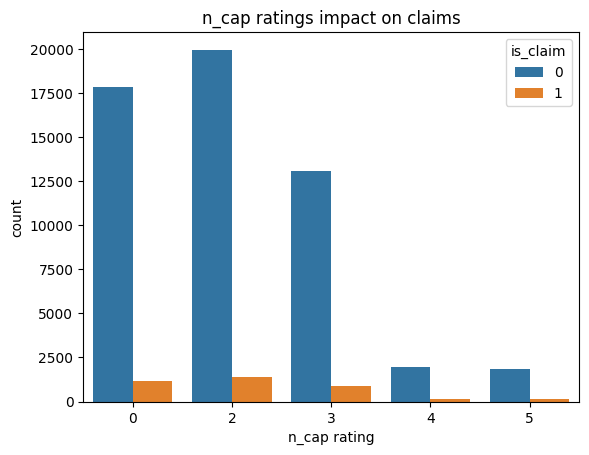

In [13]:
sns.countplot(data = final_df, x ='ncap_rating',hue = 'is_claim')
plt.title('n_cap ratings impact on claims')
plt.xlabel('n_cap rating')

plt.show()

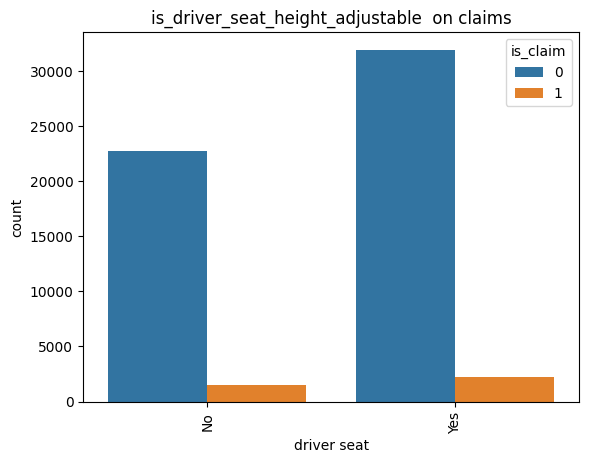

In [14]:
sns.countplot(data = final_df, x ='is_driver_seat_height_adjustable',hue = 'is_claim')
plt.title('is_driver_seat_height_adjustable  on claims')
plt.xlabel('driver seat')
plt.xticks(rotation = 90)
plt.show()

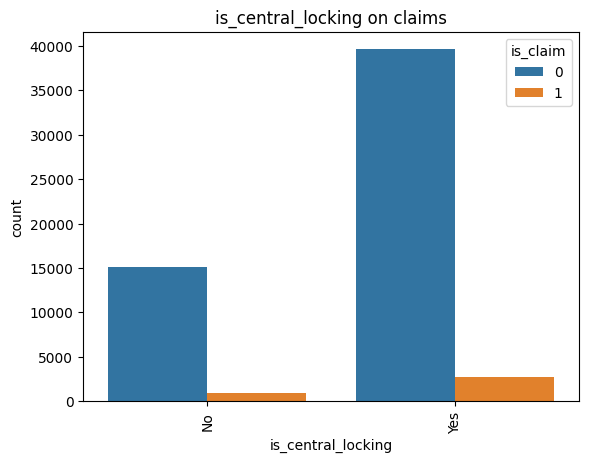

In [15]:
sns.countplot(data = final_df, x ='is_central_locking',hue = 'is_claim')
plt.title('is_central_locking on claims')
plt.xlabel('is_central_locking')
plt.xticks(rotation = 90)
plt.show()

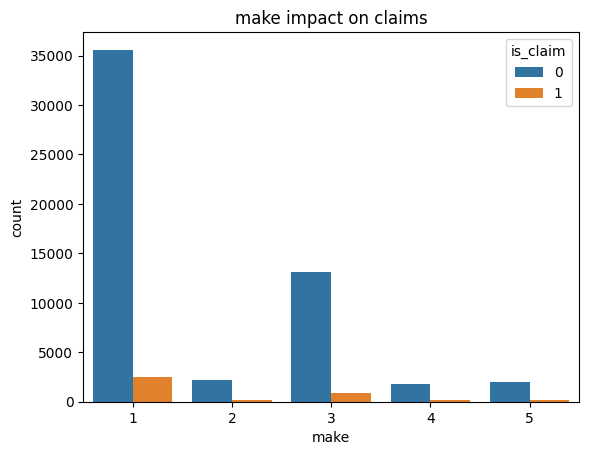

In [16]:
sns.countplot(data = final_df, x ='make',hue = 'is_claim')
plt.title('make impact on claims')
plt.xlabel('make')

plt.show()

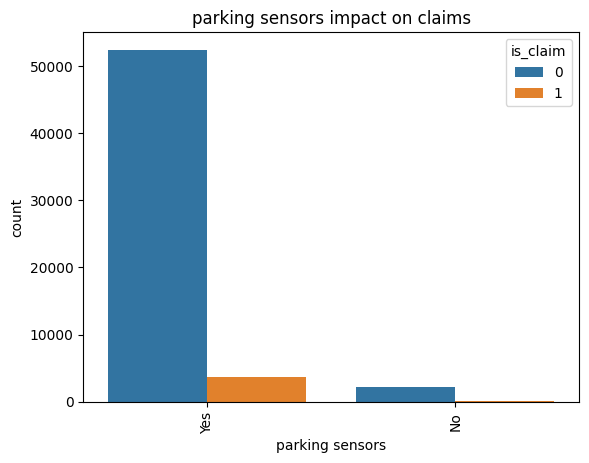

In [17]:
sns.countplot(data = final_df, x ='is_parking_sensors',hue = 'is_claim')
plt.title('parking sensors impact on claims')
plt.xlabel('parking sensors')
plt.xticks(rotation = 90)
plt.show()

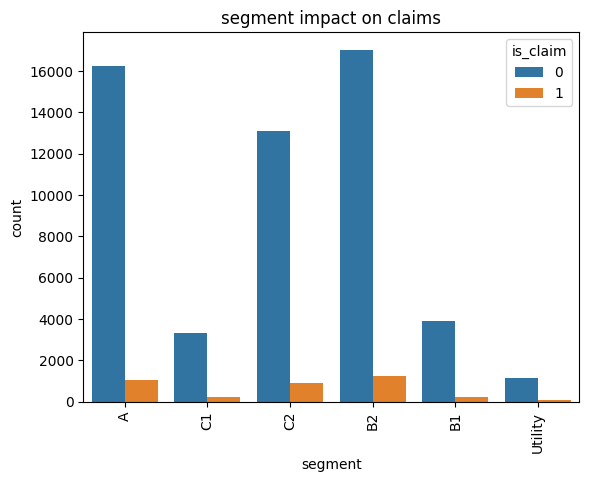

In [18]:
sns.countplot(data = final_df, x ='segment',hue = 'is_claim')
plt.title('segment impact on claims')
plt.xlabel('segment')
plt.xticks(rotation = 90)
plt.show()

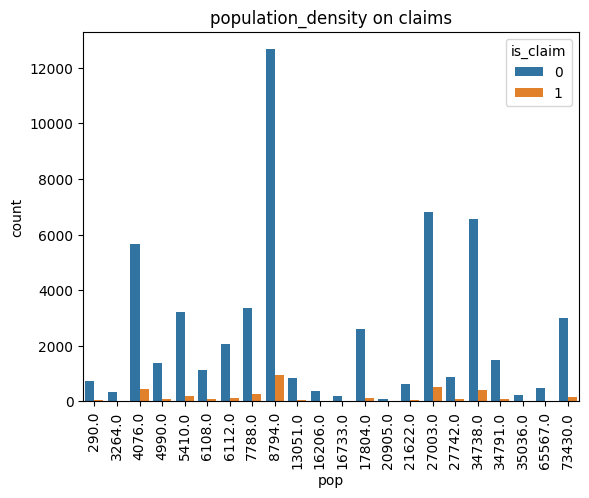

In [19]:
sns.countplot(data = final_df, x ='population_density',hue = 'is_claim')
plt.title('population_density on claims')
plt.xlabel('pop')
plt.xticks(rotation = 90)
plt.show()

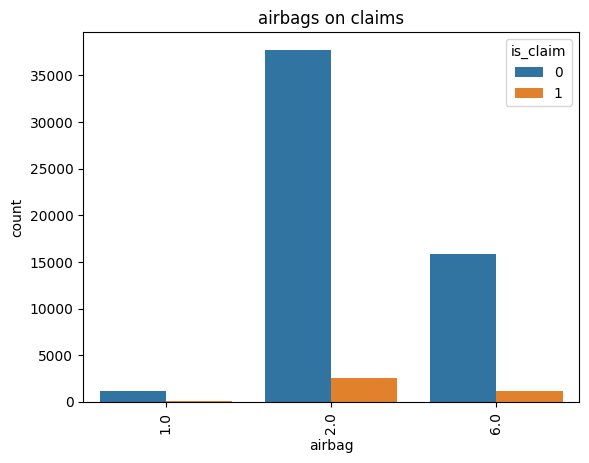

In [20]:
sns.countplot(data = final_df, x ='airbags',hue = 'is_claim')
plt.title('airbags on claims')
plt.xlabel('airbag')
plt.xticks(rotation = 90)
plt.show()

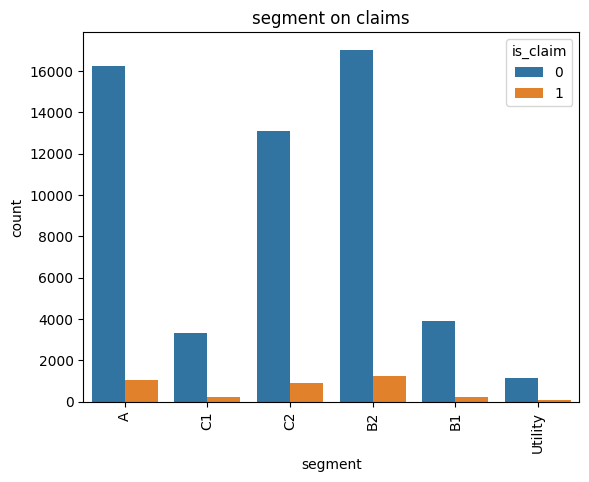

In [21]:
sns.countplot(data = final_df, x ='segment',hue = 'is_claim')
plt.title('segment on claims')
plt.xlabel('segment')
plt.xticks(rotation = 90)
plt.show()

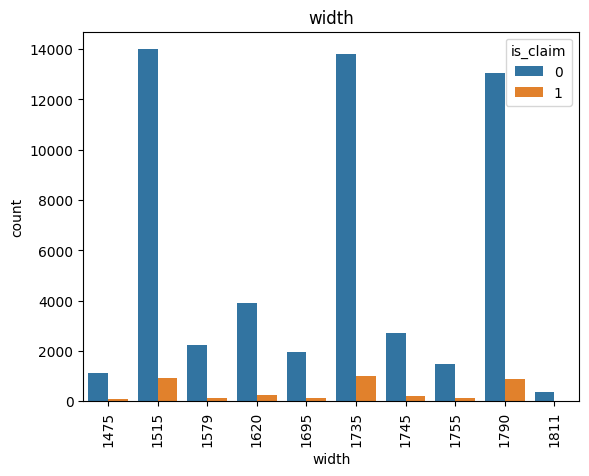

In [22]:
sns.countplot(data = final_df, x ='width',hue = 'is_claim')
plt.title('width')
plt.xlabel('width')
plt.xticks(rotation = 90)
plt.show()

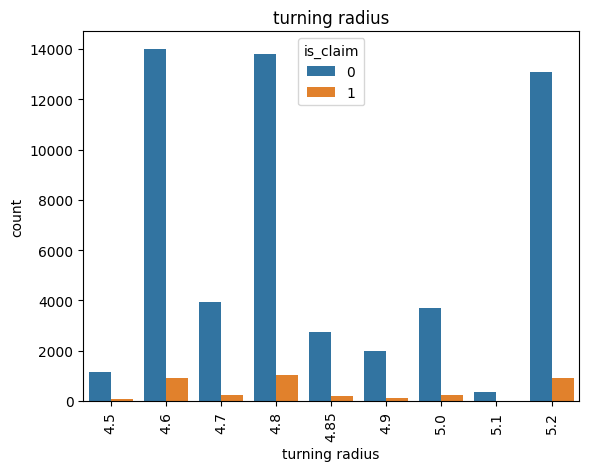

In [23]:
sns.countplot(data = final_df, x ='turning_radius',hue = 'is_claim')
plt.title('turning radius')
plt.xlabel('turning radius')
plt.xticks(rotation = 90)
plt.show()

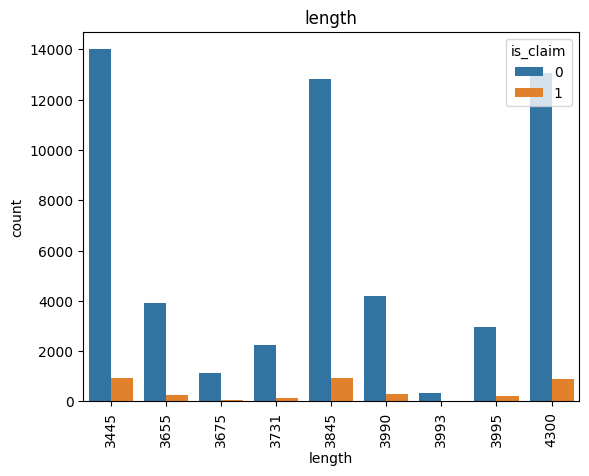

In [24]:
sns.countplot(data = final_df, x ='length',hue = 'is_claim')
plt.title('length')
plt.xlabel('length')
plt.xticks(rotation = 90)
plt.show()

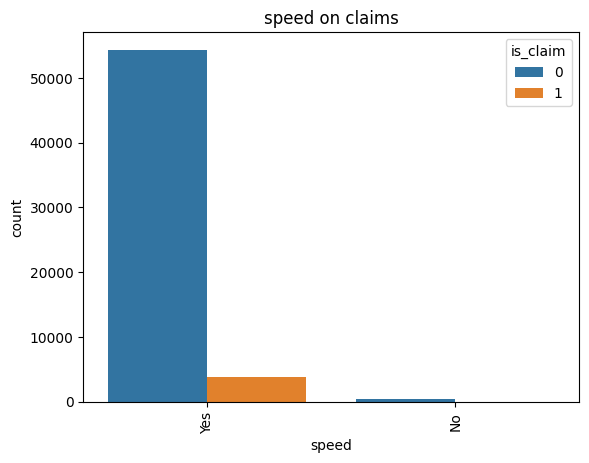

In [25]:
sns.countplot(data = final_df, x ='is_speed_alert',hue = 'is_claim')
plt.title('speed on claims')
plt.xlabel('speed')
plt.xticks(rotation = 90)
plt.show()

In [26]:
# function to calculate claim percentage
def claim_percentage(series):
    return (series.mean()*100)

In [27]:
# function to calculate percentage of claims
def percentage_of_claims(series):
    return(series.sum()/len(series))*100

In [28]:
claim_percentage(final_df.groupby('make')['is_claim'])

make
1    6.445677
2    5.379077
3    6.428060
4    6.680265
5    6.306306
Name: is_claim, dtype: float64

In [29]:
pd.pivot_table(final_df,values ='is_claim',index ='make',columns ='ncap_rating',aggfunc = percentage_of_claims)

ncap_rating,0,2,3,4,5
make,,,,,
1,6.245408,6.646653,NaN,NaN,NaN
2,NaN,5.379077,NaN,NaN,NaN
3,NaN,NaN,6.42806,NaN,NaN
4,NaN,NaN,NaN,NaN,6.680265
5,NaN,NaN,NaN,6.306306,NaN


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'F8D Petrol Engine'),
  Text(1, 0, '1.2 L K12N Dualjet'),
  Text(2, 0, '1.0 SCe'),
  Text(3, 0, '1.5 L U2 CRDi'),
  Text(4, 0, '1.5 Turbocharged Revotorq'),
  Text(5, 0, 'K Series Dual jet'),
  Text(6, 0, '1.2 L K Series Engine'),
  Text(7, 0, 'K10C'),
  Text(8, 0, 'G12B'),
  Text(9, 0, 'i-DTEC'),
  Text(10, 0, '1.5 Turbocharged Revotron')])

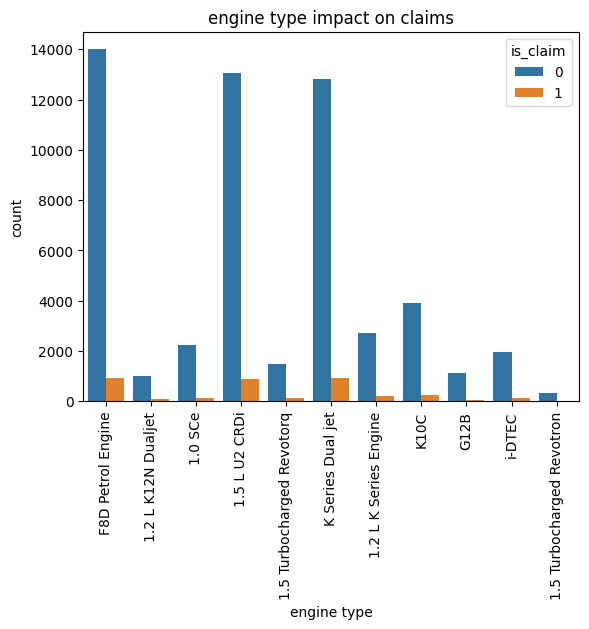

In [30]:
sns.countplot(data = final_df, x ='engine_type',hue = 'is_claim')
plt.title('engine type impact on claims')
plt.xlabel('engine type')
plt.xticks(rotation = 90)

([0, 1], [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

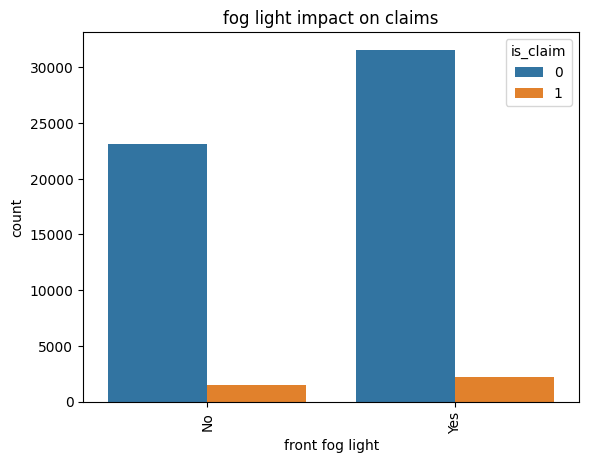

In [31]:
sns.countplot(data = final_df, x ='is_front_fog_lights',hue = 'is_claim')
plt.title('fog light impact on claims')
plt.xlabel('front fog light')
plt.xticks(rotation = 90)

In [32]:
claim_percentage(final_df.groupby('engine_type')['is_claim'])

engine_type
1.0 SCe                      5.379077
1.2 L K Series Engine        6.823610
1.2 L K12N Dualjet           7.434944
1.5 L U2 CRDi                6.428060
1.5 Turbocharged Revotorq    7.259074
1.5 Turbocharged Revotron    4.132231
F8D Petrol Engine            6.147761
G12B                         6.048053
K Series Dual jet            6.831078
K10C                         5.834334
i-DTEC                       6.306306
Name: is_claim, dtype: float64

In [33]:
pd.pivot_table(final_df,values ='is_claim',index ='engine_type',columns ='ncap_rating',aggfunc=percentage_of_claims)

ncap_rating,0,2,3,4,5
engine_type,,,,,
1.0 SCe,NaN,5.379077,NaN,NaN,NaN
1.2 L K Series Engine,6.823610,NaN,NaN,NaN,NaN
1.2 L K12N Dualjet,NaN,7.434944,NaN,NaN,NaN
1.5 L U2 CRDi,NaN,NaN,6.42806,NaN,NaN
1.5 Turbocharged Revotorq,NaN,NaN,NaN,NaN,7.259074
1.5 Turbocharged Revotron,NaN,NaN,NaN,NaN,4.132231
F8D Petrol Engine,6.147761,NaN,NaN,NaN,NaN
G12B,6.048053,NaN,NaN,NaN,NaN
K Series Dual jet,NaN,6.831078,NaN,NaN,NaN


In [34]:
pd.pivot_table(final_df,values ='is_claim',index ='rear_brakes_type',columns ='engine_type',aggfunc =percentage_of_claims)

engine_type,1.0 SCe,1.2 L K Series Engine,1.2 L K12N Dualjet,1.5 L U2 CRDi,1.5 Turbocharged Revotorq,1.5 Turbocharged Revotron,F8D Petrol Engine,G12B,K Series Dual jet,K10C,i-DTEC
rear_brakes_type,,,,,,,,,,,
Disc,NaN,NaN,NaN,6.42806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drum,5.379077,6.82361,7.434944,NaN,7.259074,4.132231,6.147761,6.048053,6.831078,5.834334,6.306306


<Axes: xlabel='rear_brakes_type', ylabel='count'>

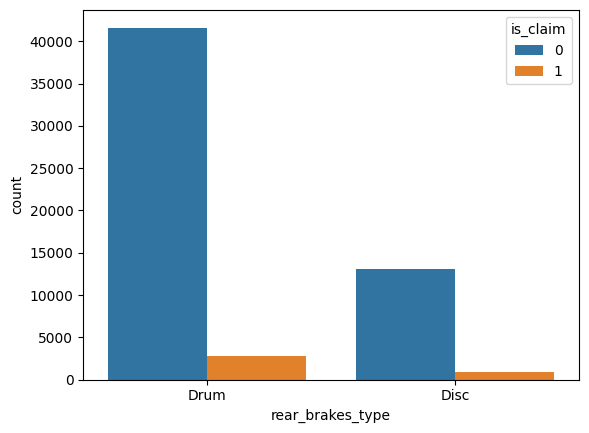

In [35]:
sns.countplot(data = final_df, x ='rear_brakes_type',hue = 'is_claim')

In [36]:
pd.pivot_table(final_df,columns =['make', 'segment', 'model', 'fuel_type', 'max_torque',
       'max_power', 'engine_type'],  values = "is_claim", index = ['is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert'] , aggfunc = sum, fill_value = 0)

make                                                                                                                                                                                                                                                                                              1  \
segment                                                                                                                                                                                                                                                                                           A   
model                                                                                                                                                                                                                                                                                            M1   
fuel_type                                                                                                                                                                                                                                                                                       CNG   
max_torque                                                                                                                                                                                                                                                                             60Nm@3500rpm   
max_power                                                                                                                                                                                                                                                                          40.36bhp@6000rpm   
engine_type                                                                                                                                                                                                                                                                       F8D Petrol Engine   
is_esc is_adjustable_steering is_tpms is_parking_sensors is_parking_camera rear_brakes_type is_rear_window_defogger is_brake_assist is_power_door_locks is_central_locking is_power_steering is_driver_seat_height_adjustable is_day_night_rear_view_mirror is_ecw is_speed_alert                     
No     No                     No      No                 Yes               Drum             No                      No              Yes                 Yes                Yes               No                               Yes                           Yes    Yes                            0   
                                      Yes                No                Drum             No                      No              No                  No                 No                No                               No                            No     Yes                            0   
                                                                                                                                                                           Yes               No                               No                            No     Yes                          917   
                                                                                                                                    Yes                 Yes                Yes               No                               No                            Yes    Yes                            0   
       Yes                    No      Yes                No                Drum             No                      No              Yes                 Yes                Yes               No                               No                            Yes    Yes                            0   
                                                                                                                    Yes             Yes                 Yes          

<Axes: >

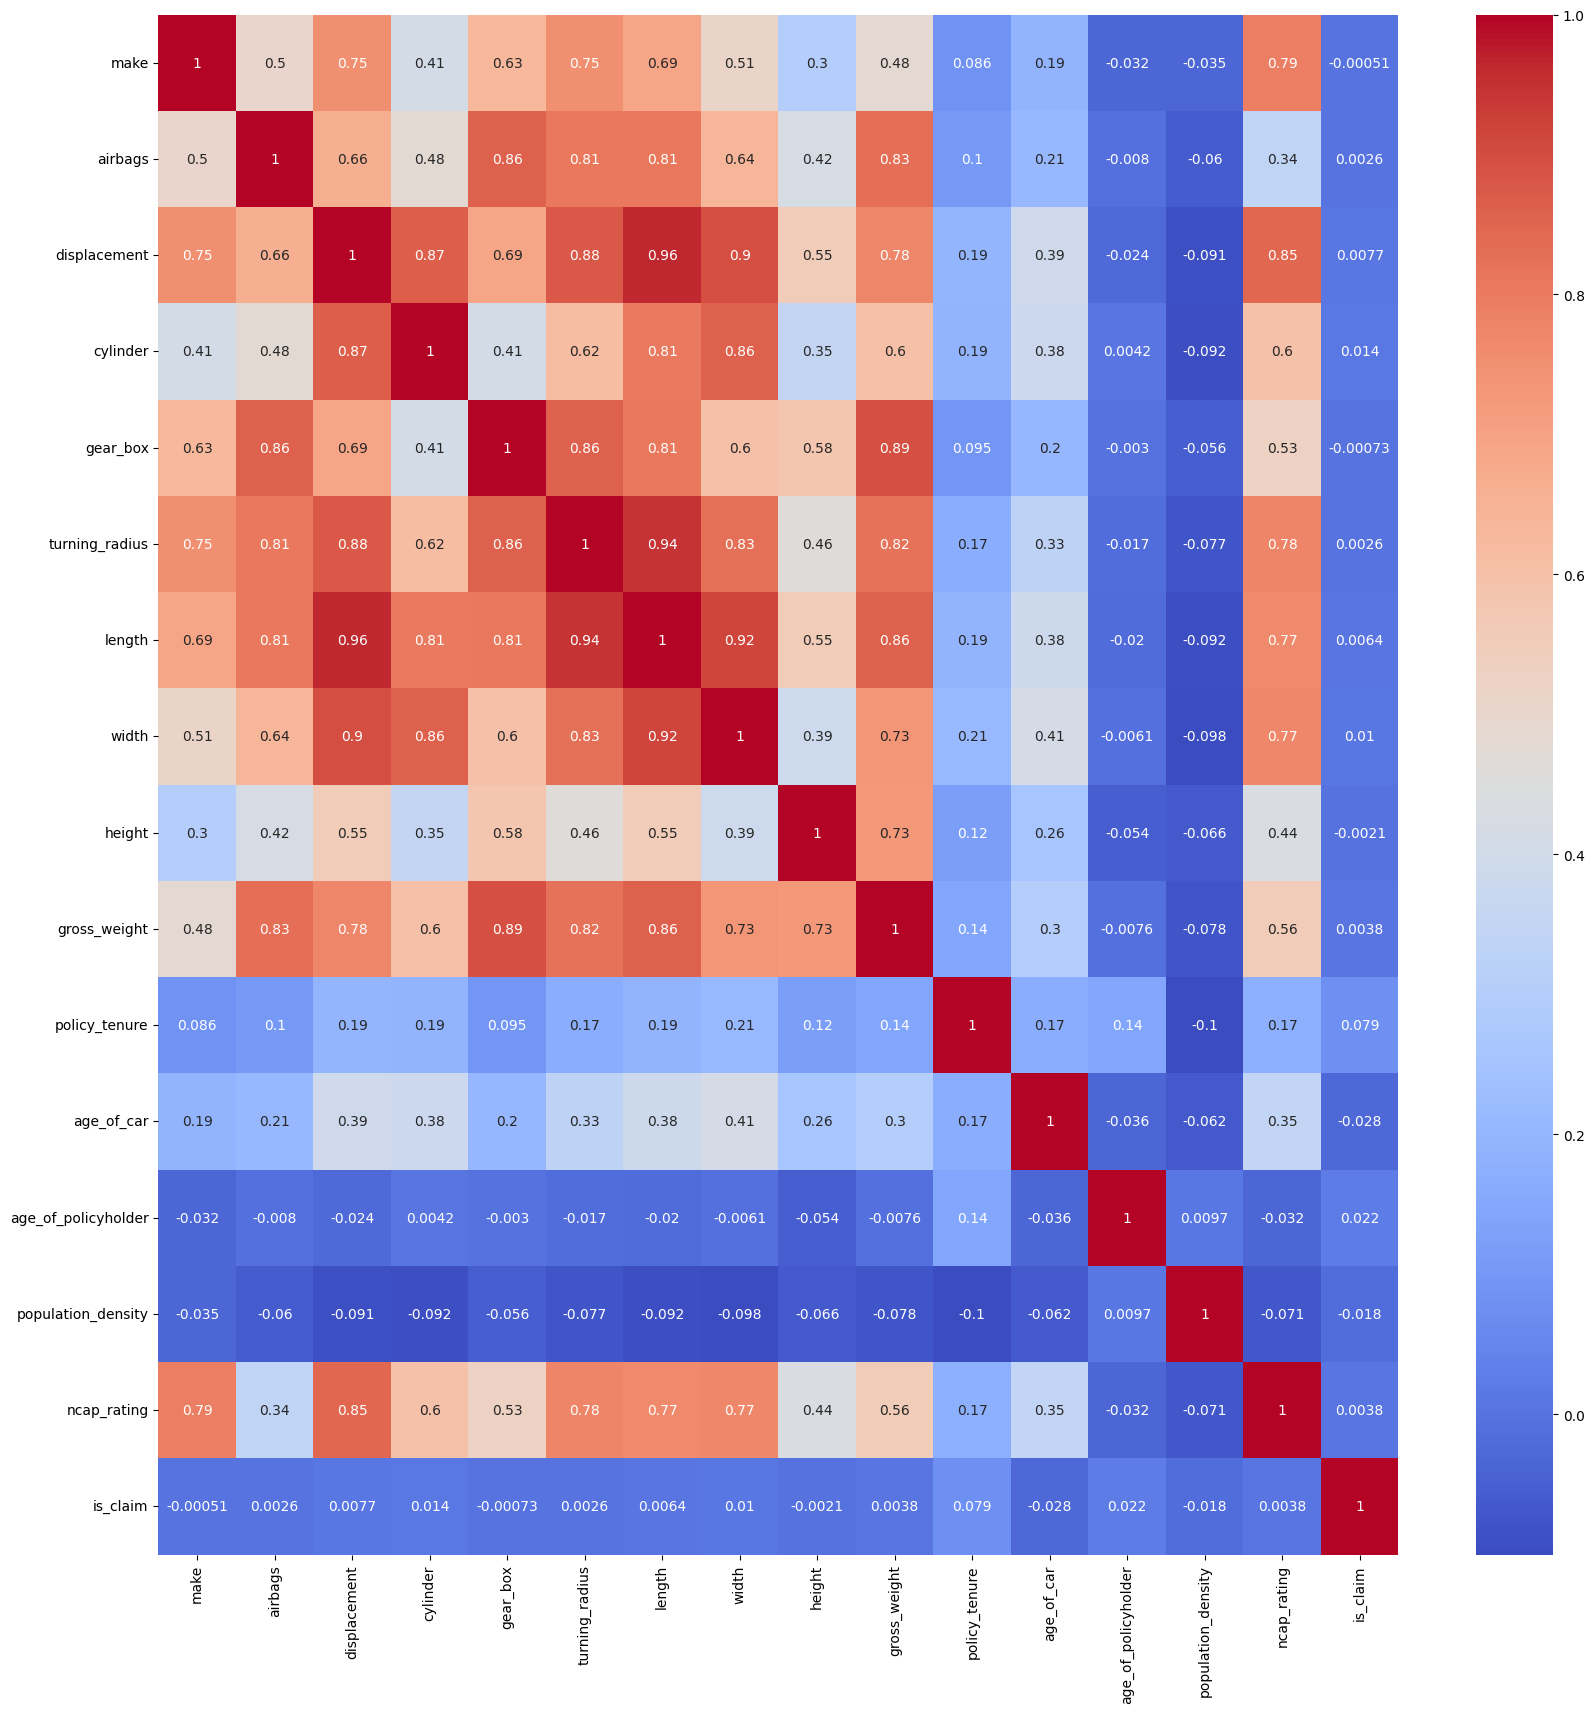

In [37]:
correlation_matrix = final_df.corr(numeric_only = True)
plt.figure(figsize =(20,20))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')

In [38]:
final_copy = final_df
final_copy.replace({'Yes': 1, 'No': 0}, inplace = True)

,policy_id,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,...,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,ncap_rating,is_claim
0,ID00001,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2.0,0,...,0,0,1,0.515874,0.05,0.644231,C1,4990.0,0,0
1,ID00002,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2.0,0,...,0,0,1,0.672619,0.02,0.375000,C2,27003.0,0,0
2,ID00003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2.0,0,...,0,0,1,0.841110,0.02,0.384615,C3,4076.0,0,0
3,ID00004,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2.0,1,...,1,1,1,0.900277,0.11,0.432692,C4,21622.0,2,0
4,ID00005,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2.0,0,...,1,1,1,0.596403,0.11,0.634615,C5,34738.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58507,ID58508,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2.0,0,...,0,0,1,0.958988,0.02,0.365385,C10,73430.0,0,0
58511,ID58512,1,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2.0,0,...,1,1,1,1.038564,0.11,0.480769,C8,8794.0,2,0
58512,ID58513,1,B1,M8,CNG,82.1Nm@3400rpm,55.92bhp@5300rpm,K10C,2.0,0,...,0,1,1,0.294251,0.07,0.509615,C10,73430.0,2,0
58513,ID58514,3,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6.0,1,...,0,1,1,0.724399,0.06,0.307692,C11,6108.0,3,0


Text(0.5, 1.0, 'correlation heat map')

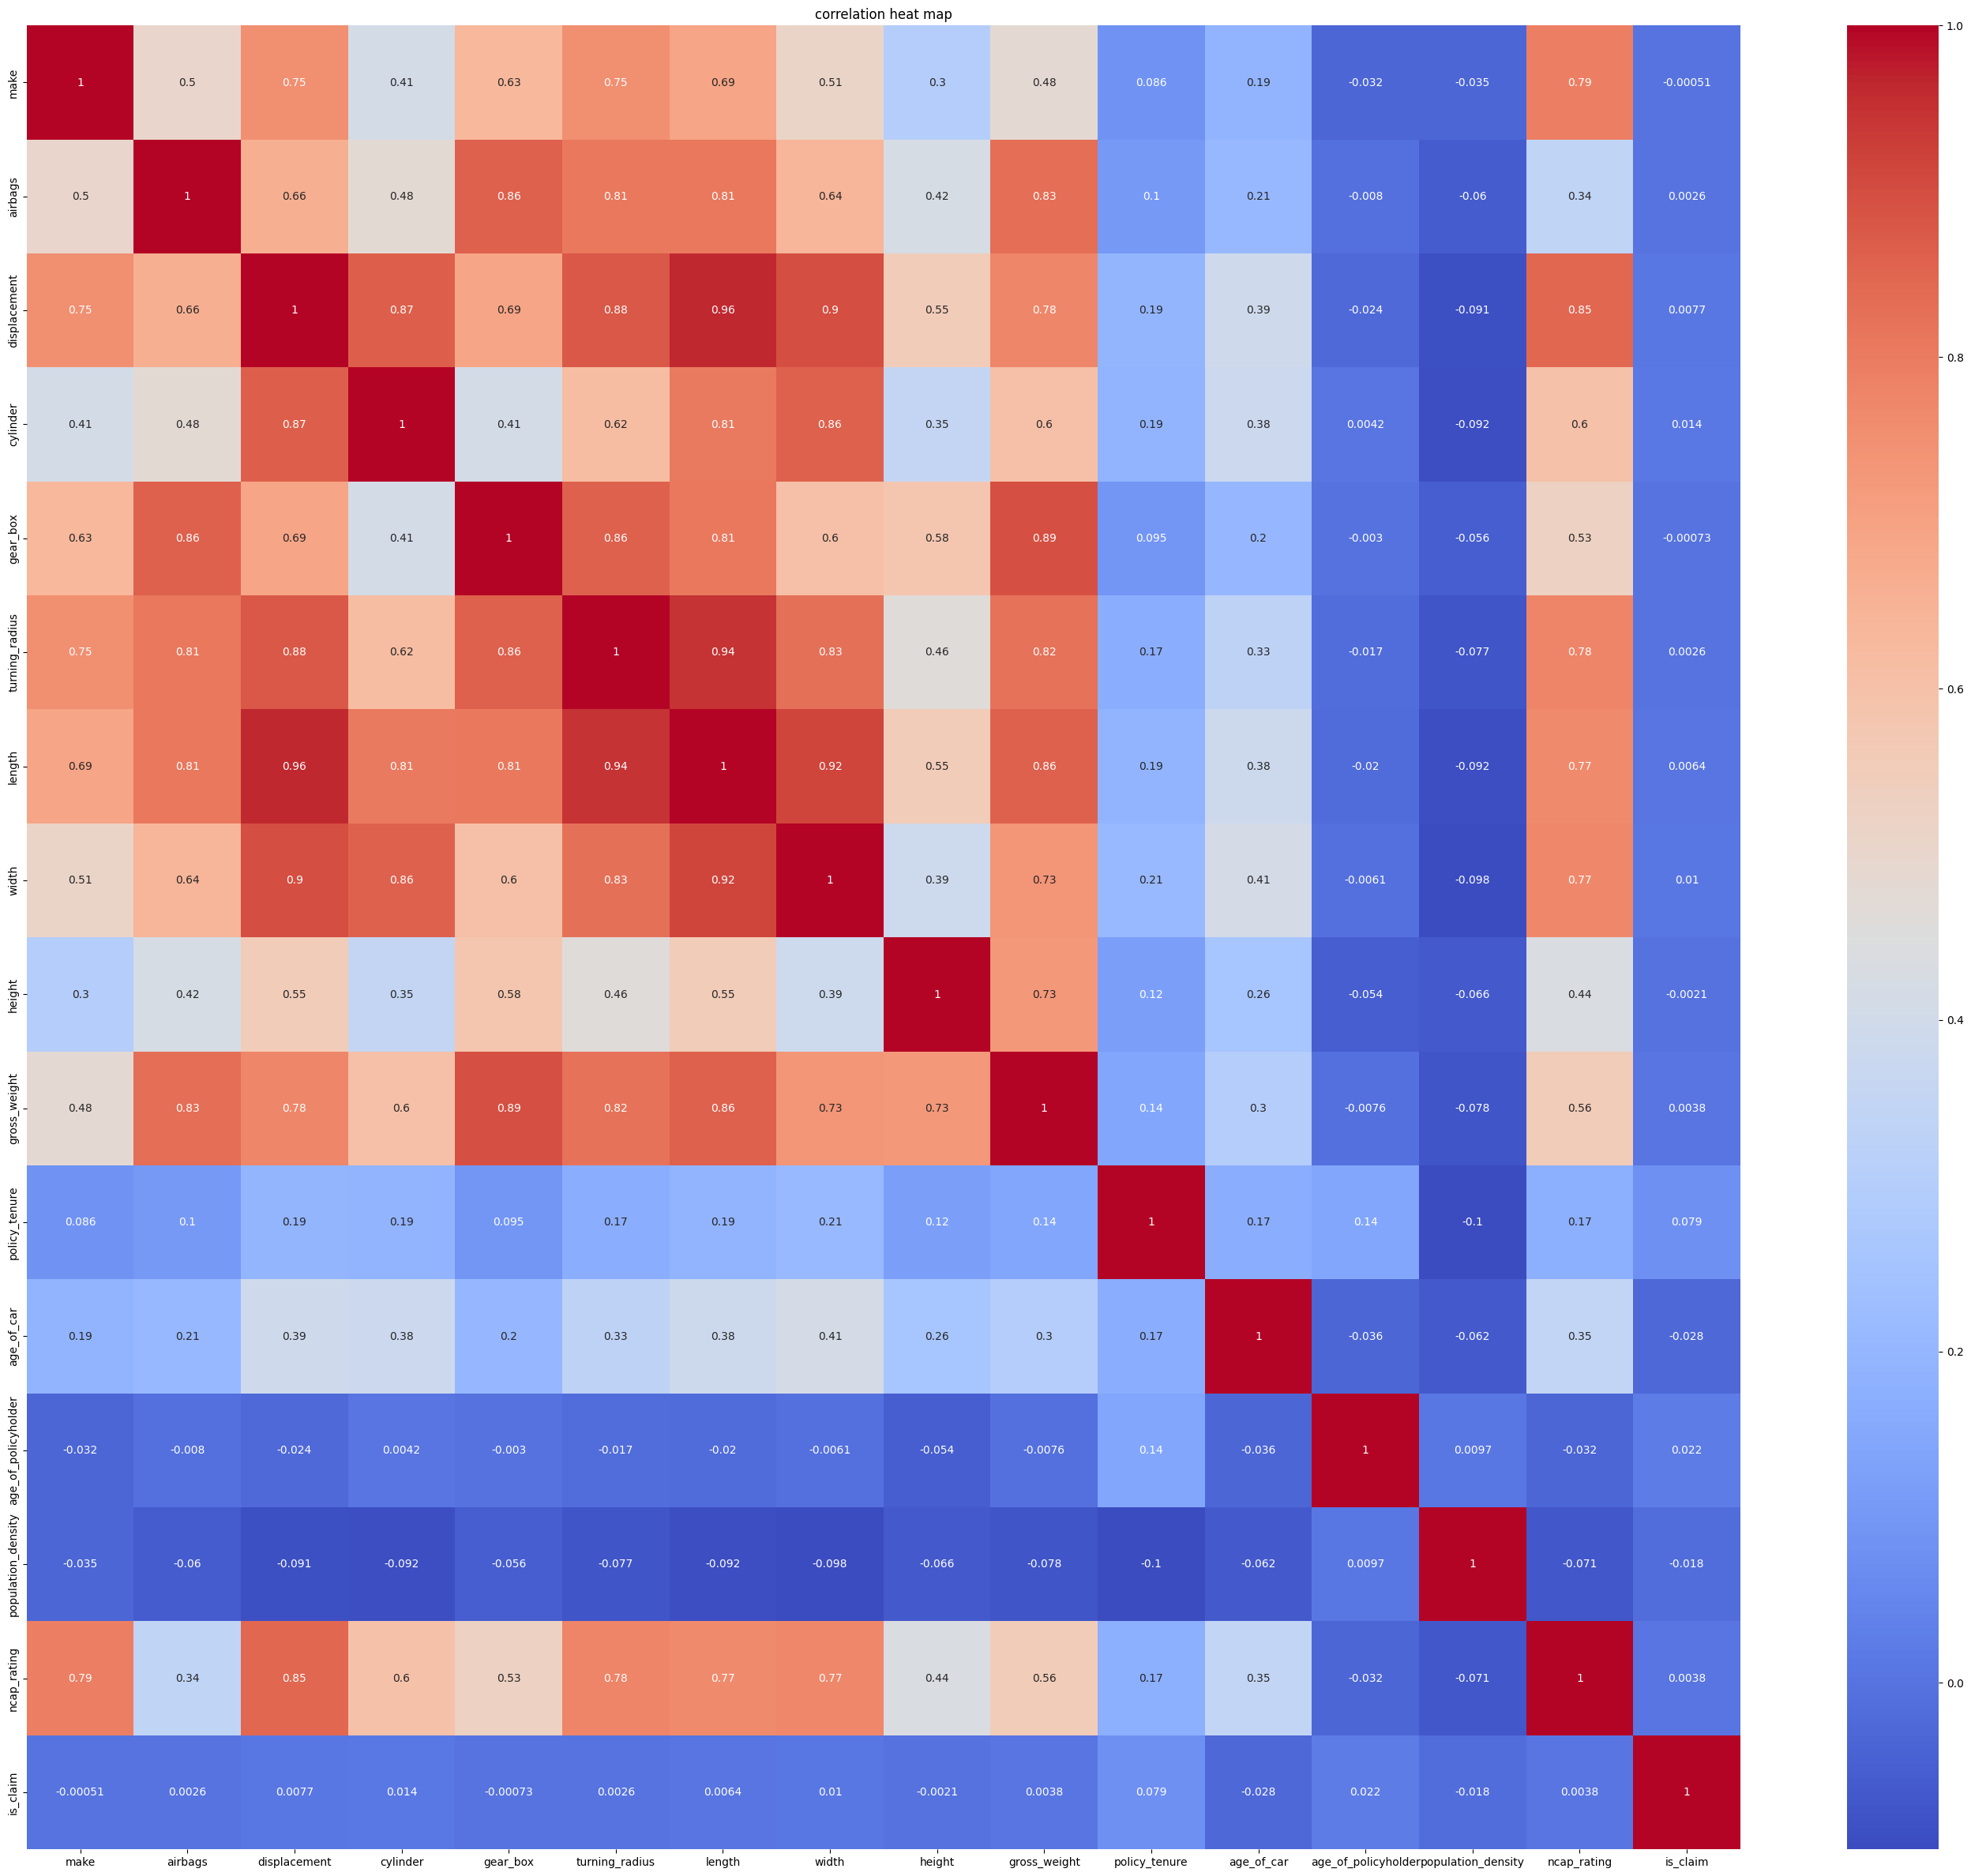

In [39]:
correlation_matrix = final_copy.corr(numeric_only = True)
plt.figure(figsize =(35,30))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title('correlation heat map')

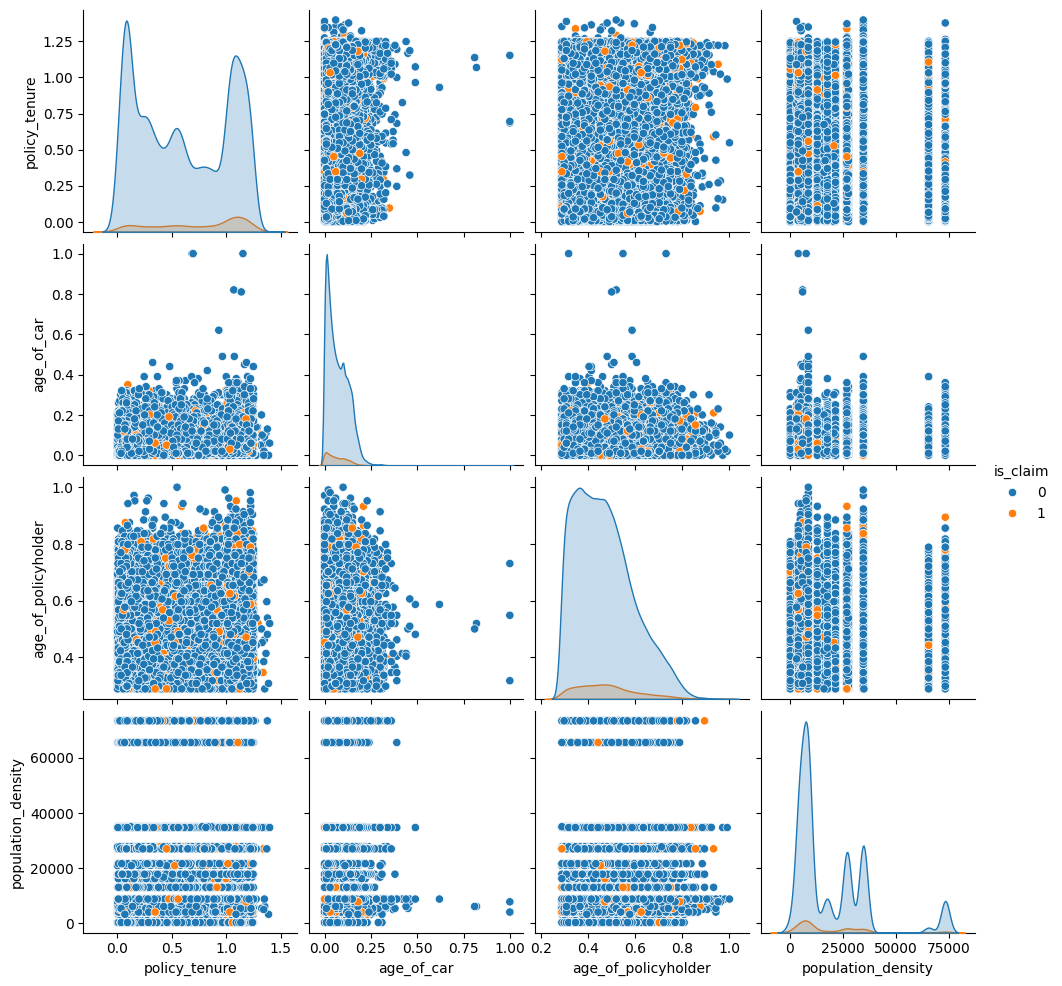

In [40]:
columns = ['policy_tenure', 'age_of_car', 'age_of_policyholder',
           'area_cluster', 'population_density','is_claim']
sns.pairplot(final_copy[columns], hue ='is_claim', diag_kind ='auto')

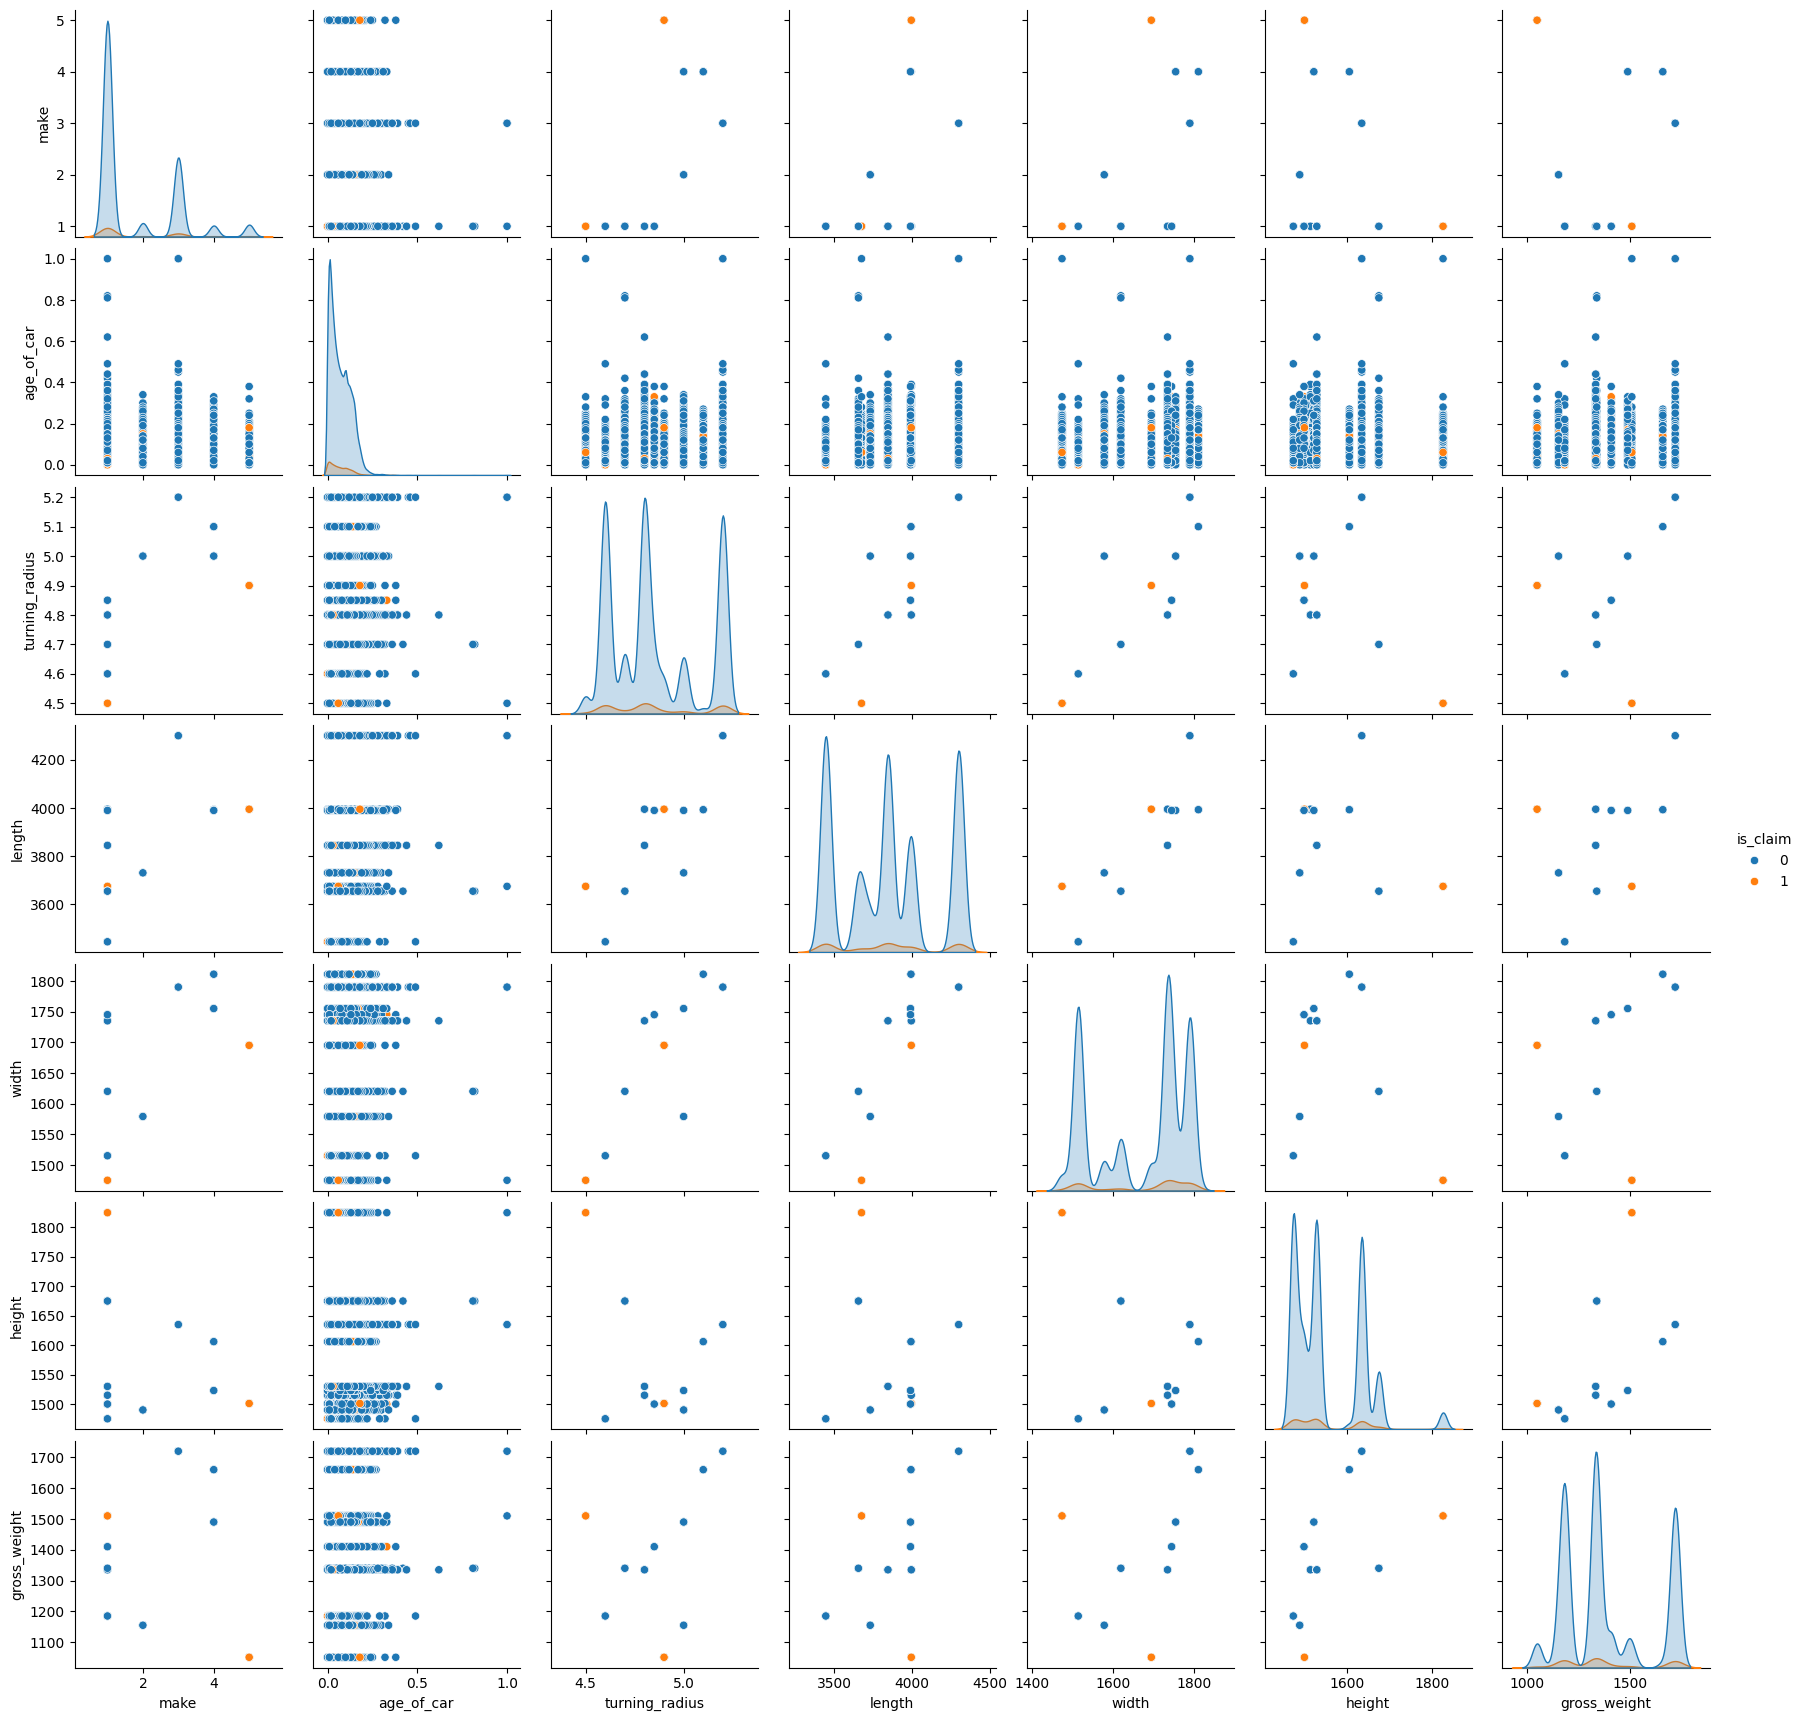

In [41]:
columns = ['make', 'segment', 'model','is_claim','age_of_car','turning_radius',
       'length', 'width', 'height', 'gross_weight']

sns.pairplot(final_copy[columns], hue ='is_claim')

### Classification Algorithms

#### Data Preparation

In [42]:
final_df.columns

Index(['policy_id', 'make', 'segment', 'model', 'fuel_type', 'max_torque',
       'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'policy_tenure', 'age_of_car',
       'age_of_policyholder', 'area_cluster', 'population_density',
       'ncap_rating', 'is_claim'],
      dtype='str')

In [43]:
final_df.drop('policy_id', axis = 1, inplace = True)

In [44]:
#One hot encoding
final_df = pd.get_dummies(final_df, drop_first=True)

In [45]:
#Using pearson correlation to identify that dependency as target varible is binary
corr_matrix = final_df.corr(method = 'pearson')
df_importance = corr_matrix['is_claim'].sort_values(ascending=False)
new_df_imp = df_importance.to_frame()
new_df_imp

,is_claim
is_claim,1.000000
policy_tenure,0.079091
age_of_policyholder,0.022402
is_adjustable_steering_1,0.014028
area_cluster_C14,0.013680
...,...
area_cluster_C7,-0.010950
area_cluster_C9,-0.012800
area_cluster_C10,-0.016604
population_density,-0.017865


In [46]:
##Split train test data
df_data = final_df.sample(n = len(final_df), random_state = 42)
df_data = df_data.reset_index(drop = True)

In [47]:
df_valid_test = df_data.sample(frac = 0.30,random_state = 42)

In [48]:
df_test = df_valid_test.sample(frac = 0.50,random_state=42)
df_valid = df_valid_test.drop(df_test.index)

In [49]:
df_train_all = df_data.drop(df_valid_test.index)

In [50]:
#check if new dfs are balanced or not
print('test distribution:',(df_test.groupby('is_claim').size()))
print('valid distribution:',(df_valid.groupby('is_claim').size()))
print('train distribution:',(df_train_all.groupby('is_claim').size()))

test distribution: is_claim
0    8197
1     569
dtype: int64
valid distribution: is_claim
0    8228
1     539
dtype: int64
train distribution: is_claim
0    38276
1     2633
dtype: int64


In [51]:
#Above stats confirms it's an imbalanced dataset. 
#split train data into positive and negatives
rows_pos = df_train_all.is_claim == 1
df_train_pos = df_train_all.loc[rows_pos]
df_train_neg = df_train_all.loc[~rows_pos]

#merge balance data
df_train = pd.concat([df_train_pos,df_train_neg.sample(n = len(df_train_pos), random_state = 42)],axis = 0)

#shuffle samples
df_train = df_train.sample(n = len(df_train), random_state = 42).reset_index(drop= True)

print('train distribution:',(df_train.groupby('is_claim').size()))

train distribution: is_claim
0    2633
1    2633
dtype: int64


In [52]:
#split valid data into positive and negatives
rows_pos = df_valid.is_claim == 1
df_valid_pos = df_valid.loc[rows_pos]
df_valid_neg = df_valid.loc[~rows_pos]

#merge balance data
df_valid = pd.concat([df_valid_pos,df_valid_neg.sample(n = len(df_valid_pos), random_state = 42)],axis = 0)

#shuffle samples
df_valid = df_valid.sample(n = len(df_valid), random_state = 42).reset_index(drop= True)

print('train distribution:',(df_valid.groupby('is_claim').size()))

train distribution: is_claim
0    539
1    539
dtype: int64


In [53]:
#split test data into positive and negatives
rows_pos = df_test.is_claim == 1
df_test_pos = df_test.loc[rows_pos]
df_test_neg = df_test.loc[~rows_pos]

#merge balance data
df_test = pd.concat([df_test_pos,df_test_neg.sample(n = len(df_test_pos), random_state = 42)],axis = 0)

#shuffle samples
df_test = df_test.sample(n = len(df_test), random_state = 42).reset_index(drop= True)

print('train distribution:',(df_valid.groupby('is_claim').size()))

train distribution: is_claim
0    539
1    539
dtype: int64


In [54]:
##create x and y matrics for input to ML packages(isolating target varible)
X_train = df_train.drop(['is_claim'], axis=1)
X_train_all = df_train_all.drop(['is_claim'], axis=1)
X_valid = df_valid.drop(['is_claim'], axis=1)

y_train = df_train['is_claim'].values
y_valid = df_valid['is_claim'].values

print('training all shape:',X_train_all.shape)
print('train shape:',X_train.shape,y_train.shape)
print('valid shape:',X_valid.shape,y_valid.shape)

training all shape: (40909, 100)
train shape: (5266, 100) (5266,)
valid shape: (1078, 100) (1078,)


In [55]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
import time

#### Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [57]:
logreg = LogisticRegression(random_state=42)
t1 = time.time()

In [58]:
logreg.fit(X_train,y_train)

/Users/snigdhasinha/Desktop/BU MSCS/DS Tools & Application/predictive_insurance_model/insurance_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [59]:
t2 = time.time()
pred1 = logreg.predict(X_valid)
t2 = time.time()

In [60]:
t = t2 - t1
print(f"time taken:{t} s")

time taken:2.4852170944213867 s


In [61]:
ts1 = accuracy_score(y_valid, pred1)*100  #test accuracy
trn1 = accuracy_score(y_train, logreg.predict(X_train))*100  #train accuracy
cmdt = confusion_matrix(y_valid, pred1)  

In [62]:
cmdt = confusion_matrix(y_valid, pred1)  
Sen1 = cmdt[1,1]/(cmdt[1,1]+cmdt[0,1])
Spc1 = cmdt[0,0]/(cmdt[0,0]+cmdt[1,0])
fnr1 = 1-Sen1

In [63]:
print('\nLogReg model \n\nClassification report for test data:\n\n',classification_report(y_valid, pred1))
print('\nConfusion matrix for test data:\n', cmdt)
print('\nSensitivity : ', cmdt[1,1]/(cmdt[1,1]+cmdt[0,1])) 
print('Specificity : ', cmdt[0,0]/(cmdt[0,0]+cmdt[1,0]))


LogReg model 

Classification report for test data:

               precision    recall  f1-score   support

           0       0.52      0.61      0.56       539
           1       0.53      0.44      0.48       539

    accuracy                           0.53      1078
   macro avg       0.53      0.53      0.52      1078
weighted avg       0.53      0.53      0.52      1078


Confusion matrix for test data:
 [[329 210]
 [302 237]]

Sensitivity :  0.5302013422818792
Specificity :  0.5213946117274167


True Neg:329
False Pos:210
False Neg:302
True Pos:237


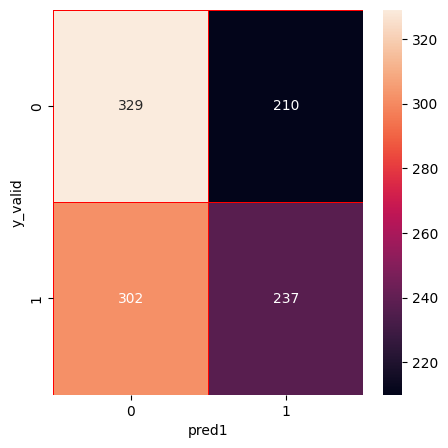

In [64]:
tn,fp,fn,tp = confusion_matrix(y_valid,pred1).ravel()
print(f'True Neg:{tn}')
print(f'False Pos:{fp}')
print(f'False Neg:{fn}')
print(f'True Pos:{tp}') 
#confusion matrix heat map
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmdt,annot = True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("pred1")
plt.ylabel("y_valid")
plt.show()

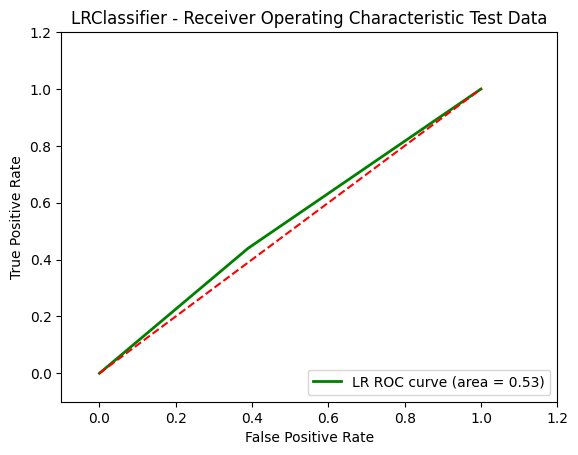

In [65]:
#roc curve
fpr1,tpr1,thres1 = roc_curve(y_valid, pred1)   
roc_auc1 = auc(fpr1, tpr1)   
plt.title('LRClassifier - Receiver Operating Characteristic Test Data') 
plt.plot(fpr1, tpr1, color ='green', lw = 2, label='LR ROC curve (area = %0.2f)' % roc_auc1) 
plt.legend(loc='lower right')    
plt.plot([0,1],[0,1],'r--')      
plt.xlim([-0.1,1.2])
plt.ylim([-0.1,1.2])             
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')
plt.show()

In [66]:
from sklearn.tree import DecisionTreeClassifier

In [67]:
# Defining model
tree = DecisionTreeClassifier(max_depth = 10,criterion = 'gini',random_state = 42)  

In [68]:
t1 = time.time()
tree.fit(X_train,y_train)
pred2 = tree.predict(X_valid)
t2 = time.time()

In [69]:
t = t2 - t1
print(f"time taken for model: {t} s")

time taken for model: 0.0650019645690918 s


In [70]:
ts2 = accuracy_score(y_valid, pred2)*100  #test accuracy
trn2 = accuracy_score(y_train, tree.predict(X_train))*100  #train accuracy
cmdt = confusion_matrix(y_valid, pred2)
Sen2 = cmdt[1,1]/(cmdt[1,1]+cmdt[0,1])
Spc2 = cmdt[0,0]/(cmdt[0,0]+cmdt[1,0])
fnr2 = 1-Sen2

In [71]:
print('\nDecisionTree model \n\nClassification report for test data:\n\n',classification_report(y_valid, pred2))
print('\nConfusion matrix for test data:\n', cmdt)
print('\nSensitivity : ', cmdt[1,1]/(cmdt[1,1]+cmdt[0,1])) 
print('Specificity : ', cmdt[0,0]/(cmdt[0,0]+cmdt[1,0]))


DecisionTree model 

Classification report for test data:

               precision    recall  f1-score   support

           0       0.54      0.54      0.54       539
           1       0.54      0.55      0.55       539

    accuracy                           0.54      1078
   macro avg       0.54      0.54      0.54      1078
weighted avg       0.54      0.54      0.54      1078


Confusion matrix for test data:
 [[292 247]
 [244 295]]

Sensitivity :  0.544280442804428
Specificity :  0.5447761194029851


True Neg:292
False Pos:247
False Neg:244
True Pos:295


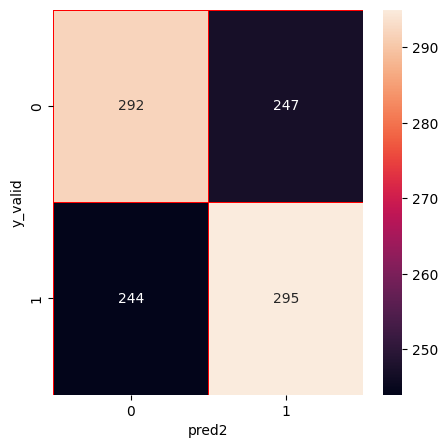

In [72]:
tn,fp,fn,tp = confusion_matrix(y_valid,pred2).ravel()
print(f'True Neg:{tn}')
print(f'False Pos:{fp}')
print(f'False Neg:{fn}')
print(f'True Pos:{tp}') 
#confusion matrix heat map
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmdt,annot = True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("pred2")
plt.ylabel("y_valid")
plt.show()

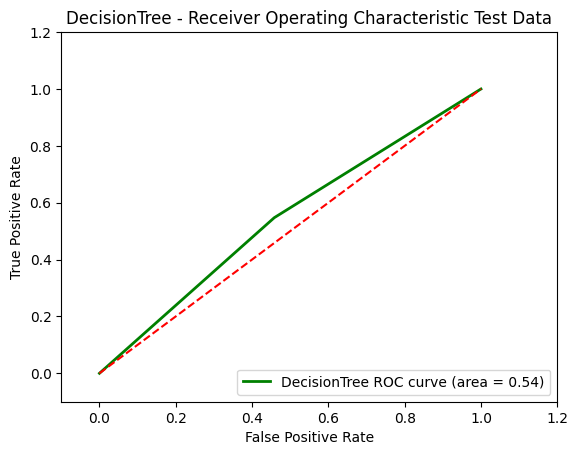

In [73]:
#roc curve
fpr2,tpr2,thres2 = roc_curve(y_valid, pred2) 
roc_auc2 = auc(fpr2, tpr2)
plt.title('DecisionTree - Receiver Operating Characteristic Test Data') 
plt.plot(fpr2, tpr2, color ='green', lw = 2, label='DecisionTree ROC curve (area = %0.2f)' % roc_auc2)
plt.legend(loc='lower right')    
plt.plot([0,1],[0,1],'r--')      
plt.xlim([-0.1,1.2])
plt.ylim([-0.1,1.2])             
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')
plt.show()

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [75]:
rsearch1_best_params = {'n_estimators': range(25,125,25), 
                 'max_features': ['auto', 'sqrt'],
                 'max_depth': np.arange(10, 200, 10),
                 'criterion': ['gini', 'entropy'],
                 'bootstrap': [True, False]}

In [76]:
# defining the model
RF = RandomForestClassifier(n_estimators=1000,
                         criterion='gini',
                         max_depth=12,
                         max_features='log2',
                         min_samples_leaf=1,
                         min_samples_split=5,
                         random_state=42) 

In [77]:
t1 = time.time()
RF.fit(X_train,y_train)
pred3 = RF.predict(X_valid)
t2 = time.time()

In [78]:
t = t2 - t1
print(f"execution time for model: {t} s")

execution time for model: 1.655776023864746 s


In [79]:
ts3  = accuracy_score(y_valid, pred3)*100  #test accuracy
trn3 = accuracy_score(y_train, RF.predict(X_train))*100  #train accuracy
cmdt = confusion_matrix(y_valid, pred3)  
Sen3 = cmdt[1,1]/(cmdt[1,1]+cmdt[0,1])
Spc3 = cmdt[0,0]/(cmdt[0,0]+cmdt[1,0])
fnr3 = 1-Sen3

In [80]:
print('\nRandomForestClassifier model \n\nClassification report for test data:\n\n',classification_report(y_valid, pred3))
print('\nConfusion matrix for test data:\n', cmdt)
print('\nSensitivity : ', cmdt[1,1]/(cmdt[1,1]+cmdt[0,1])) 
print('Specificity : ', cmdt[0,0]/(cmdt[0,0]+cmdt[1,0]))


RandomForestClassifier model 

Classification report for test data:

               precision    recall  f1-score   support

           0       0.60      0.55      0.57       539
           1       0.58      0.63      0.61       539

    accuracy                           0.59      1078
   macro avg       0.59      0.59      0.59      1078
weighted avg       0.59      0.59      0.59      1078


Confusion matrix for test data:
 [[296 243]
 [199 340]]

Sensitivity :  0.5831903945111492
Specificity :  0.597979797979798


True Neg:296
False Pos:243
False Neg:199
True Pos:340


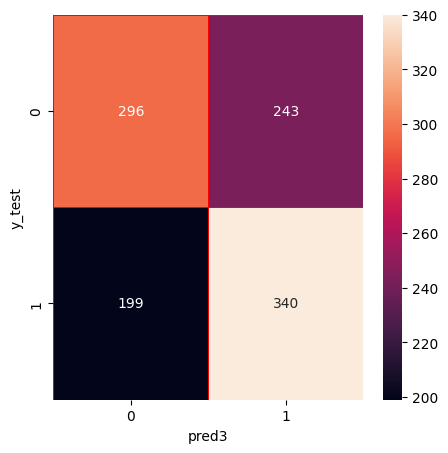

In [81]:
tn,fp,fn,tp = confusion_matrix(y_valid,pred3).ravel()
print(f'True Neg:{tn}')
print(f'False Pos:{fp}')
print(f'False Neg:{fn}')
print(f'True Pos:{tp}') 
#confusion matrix heat map
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmdt,annot = True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("pred3")
plt.ylabel("y_test")
plt.show()

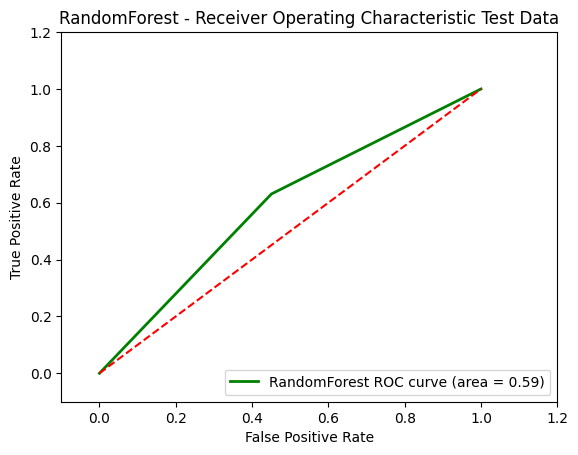

In [82]:
fpr3,tpr3,thres3 = roc_curve(y_valid, pred3) 
roc_auc3 = auc(fpr3, tpr3)
plt.title('RandomForest - Receiver Operating Characteristic Test Data') 
plt.plot(fpr3, tpr3, color ='green', lw = 2, label='RandomForest ROC curve (area = %0.2f)' % roc_auc3)
plt.legend(loc='lower right')    
plt.plot([0,1],[0,1],'r--')      
plt.xlim([-0.1,1.2])
plt.ylim([-0.1,1.2])             
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')
plt.show()

**Neural Network Classifier**

In [85]:
! pip install tensorflow

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Concatenate, Dense, Dropout, Embedding, Input, Reshape

In [ ]:
train_data = final_df.iloc[:,:720]
test_data =final_df.iloc[:,720 :]

In [ ]:
list(train_data.columns)

In [ ]:
final_df.dtypes

In [ ]:
final_copy.replace({'Yes': 1, 'No': 0}, inplace = True)
for col in final_copy:
    print(f'{col}: {final_copy[col].unique()}') 

In [ ]:
final_copy.columns

In [ ]:
final_df_enc = pd.get_dummies(data=final_copy, columns=['max_torque','max_torque','area_cluster','engine_type','max_power','rear_brakes_type','model','segment','fuel_type'])

In [ ]:
final_df_enc.sample(5)

In [ ]:
final_df_enc.dtypes

In [ ]:
cols_to_scale = ['displacement','cylinder','airbags','make']

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()
final_df_enc[cols_to_scale] = scaler.fit_transform(final_df_enc[cols_to_scale])
final_df_enc.sample(3)

In [ ]:
obj = final_df_enc.select_dtypes(include = ['object']).columns
obj

In [ ]:
final_df_enc.drop(['transmission_type', 'steering_type'], axis = 1, inplace = True)

In [ ]:
X = final_df_enc.drop('is_claim',axis='columns')
y = final_df_enc['is_claim']

In [ ]:
# Splitting test and train data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=5)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(114, input_shape=(114,), activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# opt = keras.optimizers.Adam(learning_rate=0.01)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=100)

In [ ]:
model.evaluate(X_test, y_test)

In [ ]:
yp = model.predict(X_test)
yp[:5]

In [ ]:
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [ ]:
print(classification_report(y_test,y_pred))

In [ ]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(114, input_shape=(114,), activation='relu'),
     keras.layers.Dense(65, activation='relu'),
     keras.layers.Dense(45, activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# opt = keras.optimizers.Adam(learning_rate=0.01)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20)

In [ ]:
a, trn4 = model.evaluate(X_test, y_test)

In [ ]:
a1,ts4 =  model.evaluate(X_train, y_train)

In [ ]:
ts4 = ts4*100
trn4 = trn4*100

In [ ]:
yp = model.predict(X_test)
yp[:5]

In [ ]:
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

print(classification_report(y_test,y_pred))

In [ ]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
fpr1,tpr1,thres1 = roc_curve(y_test, yp[:])   
roc_auc1 = auc(fpr1, tpr1)   
plt.title('NN - Receiver Operating Characteristic Test Data') 
plt.plot(fpr1, tpr1, color ='green', lw = 2, label='NN ROC curve (area = %0.2f)' % roc_auc1) 
plt.legend(loc='lower right')    
plt.plot([0,1],[0,1],'r--')      
plt.xlim([-0.1,1.2])
plt.ylim([-0.1,1.2])             
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')
plt.show()

#### Comapring the different classification models

In [ ]:
# Bar plots of train and test data accuracies for all models
train_acc = [trn1,trn2,trn3,trn4]
test_acc = [ts1, ts2, ts3, ts4]

n=4
r = np.arange(n)
width = 0.25
plt.bar(r, train_acc, color = 'b',width = width, edgecolor = 'black',label='train_acc')
plt.bar(r + width, test_acc, color = 'g',width = width, edgecolor = 'black',label='test_acc')
plt.xlabel("Algorithm")
plt.ylabel("Accuracy Score")
plt.title("Train-Test Accuracy Plot")

# plt.grid(linestyle='--')
plt.xticks(r + width/2,['LR','DT','RF','Neural network'])
plt.legend()

plt.show()

In [ ]:
models_df = pd.DataFrame(data= [train_acc,test_acc], columns =['LR','DT','RF','Neural network'], index = ['train', 'test'])
models_df

In [ ]:
sns.barplot(data = models_df)

In [ ]:
sns.pairplot(data = models_df)